# 🎙 FreeSWITCH `audio_bridge_thread` 工作原理交互式演示

> **目标**：用可运行的 Python 代码 + 可视化图表，**形象**地展示 FreeSWITCH 中双向音频桥接的线程模型。

## 📐 架构总览

在一个桥接通话（A ↔ B）中，FreeSWITCH 创建 **两个桥接线程**，每个方向一个：

```
     ┌──────────────┐          ┌──────────────┐
     │    UA Alice   │          │    UA Bob     │
     │  (电话 A 端)   │          │  (电话 B 端)   │
     └──────┬───────┘          └──────┬───────┘
            │ RTP (语音包)              │ RTP (语音包)
            ▼                          ▼
     ┌──────────────┐          ┌──────────────┐
     │   leg_a       │          │   leg_b       │
     │ (session_t)   │          │ (session_t)   │
     └──────┬───────┘          └──────┬───────┘
            │                          │
      ┌─────┴──────────────────────────────┴─────┐
      │                                       │
      │  Thread 1 (A->B):                     │
      │    read_frame(A) --> write_frame(B)    │
      │                                       │
      │  Thread 2 (B->A):                     │
      │    read_frame(B) --> write_frame(A)    │
      │                                       │
      └───────────────────────────────────────┘
```

**源码位置**: `src/switch_ivr_bridge.c` -> `audio_bridge_thread()`, `switch_ivr_multi_threaded_bridge()`


## 1️⃣ 基础设施：RTP 帧与呼叫腿

我们先定义模拟 RTP 帧和 FreeSWITCH `switch_core_session_t` 的基础类。


In [1]:
import socket
import struct
import threading
import time
import math
import collections
from dataclasses import dataclass, field

# -- RTP constants (simulating G.711 PCMU @ 8kHz) --
RTP_HEADER_FMT    = "!BBHII"    # version_flags, marker_pt, seq, timestamp, ssrc
RTP_HEADER_SIZE   = struct.calcsize(RTP_HEADER_FMT)  # 12 bytes
FRAME_SAMPLES     = 160   # 8kHz x 20ms
FRAME_PAYLOAD_LEN = 160   # G.711: 1 byte/sample
FRAME_INTERVAL    = 0.020 # 20ms
LOCALHOST          = "127.0.0.1"

def make_rtp_frame(seq, timestamp, ssrc, payload):
    """Pack a simplified RTP frame (maps to switch_frame_t)"""
    hdr = struct.pack(RTP_HEADER_FMT, 0x80, 0, seq & 0xFFFF, timestamp, ssrc)
    return hdr + payload

def parse_rtp_header(data):
    """Parse RTP header"""
    if len(data) < RTP_HEADER_SIZE:
        return None
    vf, mpt, seq, ts, ssrc = struct.unpack(RTP_HEADER_FMT, data[:RTP_HEADER_SIZE])
    return {"seq": seq, "ts": ts, "ssrc": ssrc, "payload_len": len(data) - RTP_HEADER_SIZE}

print("\u2705 RTP frame tools ready")
print(f"   RTP header = {RTP_HEADER_SIZE} bytes, payload = {FRAME_PAYLOAD_LEN} bytes/frame")
print(f"   Frame interval = {FRAME_INTERVAL*1000:.0f}ms ({1/FRAME_INTERVAL:.0f} frames/sec)")


✅ RTP frame tools ready
   RTP header = 12 bytes, payload = 160 bytes/frame
   Frame interval = 20ms (50 frames/sec)


## 2️⃣ `CallLeg` — 模拟 `switch_core_session_t`

每条呼叫腿（call leg）对应 FreeSWITCH 中的一个 session。它持有：
- 一个 **RTP UDP socket**（接收对端发来的语音包）
- `read_frame()` -> 对应 `switch_core_session_read_frame()` -> `switch_rtp_zerocopy_read_frame()` -> `recvfrom()`
- `write_frame()` -> 对应 `switch_core_session_write_frame()` -> `sendto()`

🔑 **关键点**：`read_frame()` 是 **阻塞** 的——线程会停在这里等待 RTP 包。这就是为什么每个桥接方向需要一个独立线程。


In [2]:
@dataclass
class CallLeg:
    """Simulates FreeSWITCH switch_core_session_t"""
    name: str
    rtp_port: int
    peer_port: int
    rtp_sock: socket.socket = None
    frames_read: int = 0
    frames_written: int = 0
    # Timestamps for visualization
    read_timestamps: list = field(default_factory=list)
    write_timestamps: list = field(default_factory=list)
    read_seqs: list = field(default_factory=list)
    write_seqs: list = field(default_factory=list)
    lock: threading.Lock = field(default_factory=threading.Lock)

    def setup(self):
        self.rtp_sock = socket.socket(socket.AF_INET, socket.SOCK_DGRAM)
        self.rtp_sock.setsockopt(socket.SOL_SOCKET, socket.SO_REUSEADDR, 1)
        self.rtp_sock.bind((LOCALHOST, self.rtp_port))
        self.rtp_sock.settimeout(0.1)

    def close(self):
        if self.rtp_sock:
            self.rtp_sock.close()
            self.rtp_sock = None

    def read_frame(self, t0):
        """Blocking read (maps to switch_core_session_read_frame -> recvfrom)"""
        try:
            data, addr = self.rtp_sock.recvfrom(4096)
            now = time.monotonic() - t0
            hdr = parse_rtp_header(data)
            with self.lock:
                self.frames_read += 1
                self.read_timestamps.append(now)
                if hdr:
                    self.read_seqs.append(hdr["seq"])
            return data
        except socket.timeout:
            return None

    def write_frame(self, frame_data, t0):
        """Write frame to peer (maps to switch_core_session_write_frame -> sendto)"""
        try:
            self.rtp_sock.sendto(frame_data, (LOCALHOST, self.peer_port))
            now = time.monotonic() - t0
            hdr = parse_rtp_header(frame_data)
            with self.lock:
                self.frames_written += 1
                self.write_timestamps.append(now)
                if hdr:
                    self.write_seqs.append(hdr["seq"])
            return True
        except Exception:
            return False

print("\u2705 CallLeg class defined")


✅ CallLeg class defined


## 3️⃣ `audio_bridge_thread` — 核心桥接线程

这是整个演示的 **核心**。对应 `src/switch_ivr_bridge.c` 中的 `audio_bridge_thread()` 函数。

**伪代码对照**（真实 FreeSWITCH C 代码 ~line 780-830）：

```c
while (bridge_is_active) {
    // Blocks here! Waiting for RTP packet or timer tick
    status = switch_core_session_read_frame(session_a, &read_frame, ...);
    if (!SWITCH_READ_ACCEPTABLE(status)) break;

    if (is_CNG_frame(read_frame)) continue;  // skip comfort noise

    // DTMF handling...

    // Forward to peer (may trigger codec conversion)
    switch_core_session_write_frame(session_b, read_frame, ...);
}
```


In [3]:
def audio_bridge_thread(read_leg, write_leg, direction, bridge_active, stats, t0):
    """
    Simulates FreeSWITCH audio_bridge_thread().
    Core loop: read_frame(source) -> write_frame(destination)
    """
    bridged = 0
    latencies = []

    while bridge_active.is_set():
        # === switch_core_session_read_frame() ===
        # Blocks waiting for RTP packet
        frame = read_leg.read_frame(t0)
        if frame is None:
            continue
        if len(frame) < RTP_HEADER_SIZE:
            continue

        t_read = time.monotonic()

        # === switch_core_session_write_frame() ===
        # Forward to peer (in real FS, may trigger codec conversion)
        if write_leg.write_frame(frame, t0):
            t_write = time.monotonic()
            latencies.append((t_write - t_read) * 1000)  # ms
            bridged += 1

    stats[direction] = {"count": bridged, "latencies": latencies}


def ua_producer(name, dest_port, ssrc, active, total_frames, t0, send_log):
    """Simulates a UA sending RTP frames every 20ms"""
    sock = socket.socket(socket.AF_INET, socket.SOCK_DGRAM)
    seq, ts = 0, 0
    for i in range(total_frames):
        if not active.is_set():
            break
        payload = bytes([int(128 + 64 * math.sin(2 * math.pi * (i*160 + j) / 160)) & 0xFF
                         for j in range(FRAME_PAYLOAD_LEN)])
        frame = make_rtp_frame(seq, ts, ssrc, payload)
        sock.sendto(frame, (LOCALHOST, dest_port))
        send_log.append((time.monotonic() - t0, seq))
        seq += 1
        ts += FRAME_SAMPLES
        time.sleep(FRAME_INTERVAL)
    sock.close()

print("\u2705 Bridge thread and UA producer functions defined")


✅ Bridge thread and UA producer functions defined


## 4️⃣ 运行模拟：`switch_ivr_multi_threaded_bridge()`

下面模拟一个 **1 秒** 的桥接通话（50 帧），启动 4 个线程：

| 线程 | 角色 | 对应 FreeSWITCH |
|------|------|-----------------|
| `UA_A` | Alice 的电话发 RTP | 远端 UA |
| `UA_B` | Bob 的电话发 RTP | 远端 UA |
| `bridge A->B` | 从 A 读、写到 B | `audio_bridge_thread` (方向1) |
| `bridge B->A` | 从 B 读、写到 A | `audio_bridge_thread` (方向2) |


In [4]:
TOTAL_FRAMES = 50   # 1 second = 50 frames x 20ms
PORT_A, PORT_B  = 17000, 17002
PORT_AP, PORT_BP = 17010, 17012

# -- Create call legs --
leg_a = CallLeg(name="leg_a (Alice)", rtp_port=PORT_A, peer_port=PORT_BP)
leg_b = CallLeg(name="leg_b (Bob)",   rtp_port=PORT_B, peer_port=PORT_AP)
leg_a.setup()
leg_b.setup()

bridge_active = threading.Event()
bridge_active.set()
bridge_stats = {}
send_log_a, send_log_b = [], []
t0 = time.monotonic()

# -- Start bridge threads (maps to switch_ivr_multi_threaded_bridge) --
threads = [
    threading.Thread(target=audio_bridge_thread,
                     args=(leg_a, leg_b, "A->B", bridge_active, bridge_stats, t0)),
    threading.Thread(target=audio_bridge_thread,
                     args=(leg_b, leg_a, "B->A", bridge_active, bridge_stats, t0)),
    threading.Thread(target=ua_producer,
                     args=("UA_A", PORT_A, 0xAA01, bridge_active, TOTAL_FRAMES, t0, send_log_a)),
    threading.Thread(target=ua_producer,
                     args=("UA_B", PORT_B, 0xBB02, bridge_active, TOTAL_FRAMES, t0, send_log_b)),
]
for t in threads:
    t.start()

threads[2].join()
threads[3].join()
time.sleep(0.3)

bridge_active.clear()
threads[0].join()
threads[1].join()

a2b = bridge_stats.get("A->B", {}).get("count", 0)
b2a = bridge_stats.get("B->A", {}).get("count", 0)

print(f"{'='*50}")
print(f"  \U0001f4ca Bridge Results")
print(f"{'='*50}")
print(f"  A->B: {a2b}/{TOTAL_FRAMES} frames bridged")
print(f"  B->A: {b2a}/{TOTAL_FRAMES} frames bridged")
print(f"  leg_a reads: {leg_a.frames_read}, writes: {leg_a.frames_written}")
print(f"  leg_b reads: {leg_b.frames_read}, writes: {leg_b.frames_written}")

if a2b >= TOTAL_FRAMES * 0.8 and b2a >= TOTAL_FRAMES * 0.8:
    print(f"\n  \u2705 Bidirectional bridge working correctly!")
else:
    print(f"\n  \u26a0\ufe0f Some frames lost")

leg_a.close()
leg_b.close()


  📊 Bridge Results
  A->B: 50/50 frames bridged
  B->A: 50/50 frames bridged
  leg_a reads: 50, writes: 50
  leg_b reads: 50, writes: 50

  ✅ Bidirectional bridge working correctly!


## 5️⃣ 可视化：帧转发时间线

下图展示每一帧从 **UA 发送 -> leg 读取 -> 桥接写入** 的时间轴，直观展示两个桥接方向的 **并行性**。


/var/folders/xk/0l93y7ps37lck71fry36ycxh0000gn/T/ipykernel_36940/3205388587.py:40: UserWarning: Glyph 129525 (\N{SPOOL OF THREAD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/walterfan/workspace/walter/freeswitch_primer/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 129525 (\N{SPOOL OF THREAD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


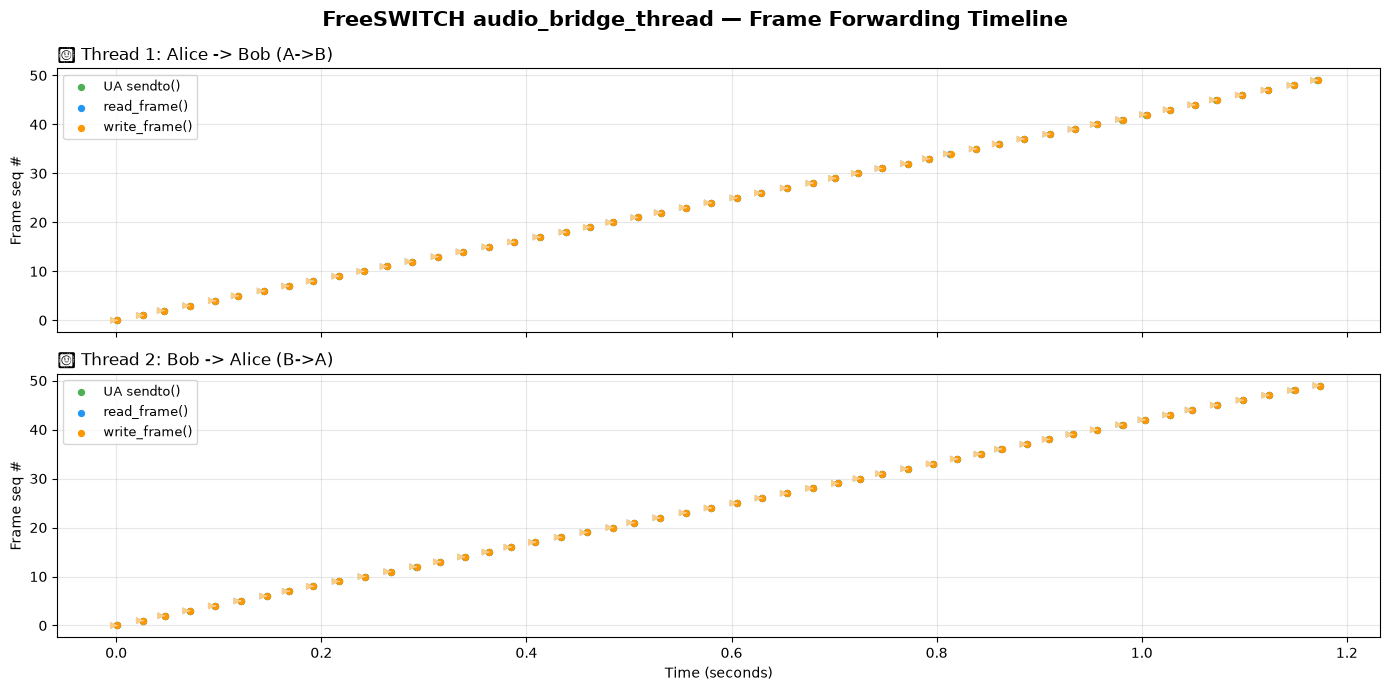

✅ Timeline chart rendered


In [5]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
fig.suptitle("FreeSWITCH audio_bridge_thread \u2014 Frame Forwarding Timeline", fontsize=15, fontweight='bold')

colors = {"send": "#4CAF50", "read": "#2196F3", "write": "#FF9800"}

for ax, direction, send_log, r_leg, w_leg, title in [
    (axes[0], "A->B", send_log_a, leg_a, leg_b,
     "\U0001f9f5 Thread 1: Alice -> Bob (A->B)"),
    (axes[1], "B->A", send_log_b, leg_b, leg_a,
     "\U0001f9f5 Thread 2: Bob -> Alice (B->A)"),
]:
    n = min(len(send_log), len(r_leg.read_timestamps), len(w_leg.write_timestamps))
    frames = np.arange(n)

    s_times = [send_log[i][0] for i in range(n)]
    r_times = r_leg.read_timestamps[:n]
    w_times = w_leg.write_timestamps[:n]

    ax.scatter(s_times, frames, c=colors["send"],  s=18, zorder=3, label="UA sendto()")
    ax.scatter(r_times, frames, c=colors["read"],  s=18, zorder=3, label="read_frame()")
    ax.scatter(w_times, frames, c=colors["write"], s=18, zorder=3, label="write_frame()")

    for i in range(n):
        ax.annotate("", xy=(r_times[i], frames[i]), xytext=(s_times[i], frames[i]),
                     arrowprops=dict(arrowstyle="-|>", color="#90CAF9", lw=0.8))
        ax.annotate("", xy=(w_times[i], frames[i]), xytext=(r_times[i], frames[i]),
                     arrowprops=dict(arrowstyle="-|>", color="#FFCC80", lw=0.8))

    ax.set_ylabel("Frame seq #")
    ax.set_title(title, fontsize=12, loc='left')
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3)

axes[1].set_xlabel("Time (seconds)")
plt.tight_layout()
plt.show()
print("\u2705 Timeline chart rendered")


## 6️⃣ 可视化：桥接延迟分布

每帧的桥接延迟 = `write_frame()` 完成时刻 − `read_frame()` 返回时刻。

这个延迟在真实 FreeSWITCH 中主要由以下因素决定：
- 编解码转换（如果 A/B 使用不同 codec）
- media bug 处理（录音、语音识别等）
- 内核网络栈的 sendto() 开销


/var/folders/xk/0l93y7ps37lck71fry36ycxh0000gn/T/ipykernel_36940/3093486514.py:21: UserWarning: Glyph 129525 (\N{SPOOL OF THREAD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


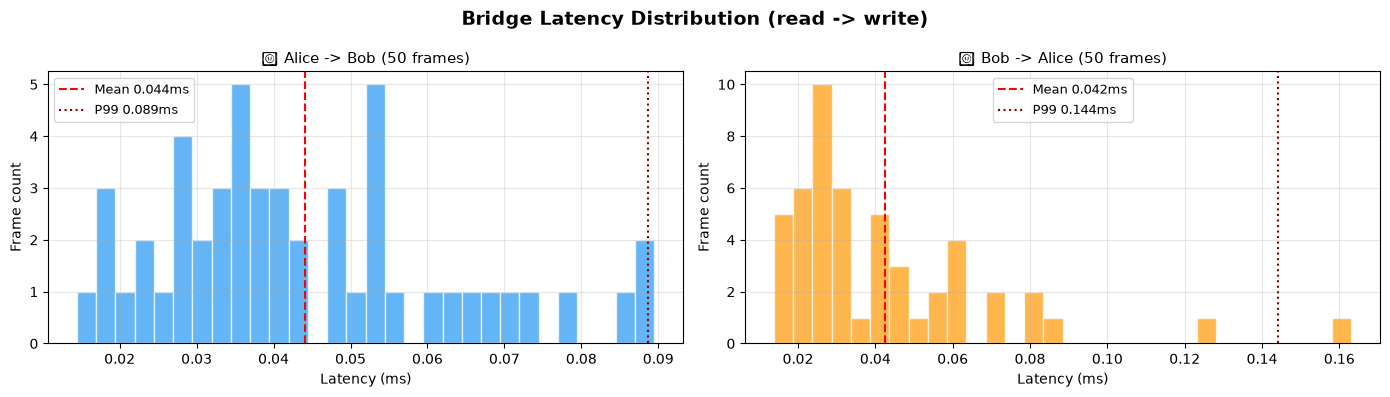

✅ Latency distribution chart rendered


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Bridge Latency Distribution (read -> write)", fontsize=14, fontweight='bold')

for ax, direction, color, label in [
    (axes[0], "A->B", "#2196F3", "Alice -> Bob"),
    (axes[1], "B->A", "#FF9800", "Bob -> Alice"),
]:
    lats = bridge_stats.get(direction, {}).get("latencies", [])
    if lats:
        ax.hist(lats, bins=30, color=color, alpha=0.7, edgecolor='white')
        ax.axvline(np.mean(lats), color='red', ls='--', lw=1.5,
                   label=f'Mean {np.mean(lats):.3f}ms')
        ax.axvline(np.percentile(lats, 99), color='darkred', ls=':', lw=1.5,
                   label=f'P99 {np.percentile(lats, 99):.3f}ms')
        ax.legend(fontsize=9)
    ax.set_xlabel("Latency (ms)")
    ax.set_ylabel("Frame count")
    ax.set_title(f"\U0001f9f5 {label} ({len(lats)} frames)", fontsize=11)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("\u2705 Latency distribution chart rendered")


## 7️⃣ 可视化：线程架构图

用 matplotlib 绘制 FreeSWITCH 桥接通话的线程与数据流架构图。


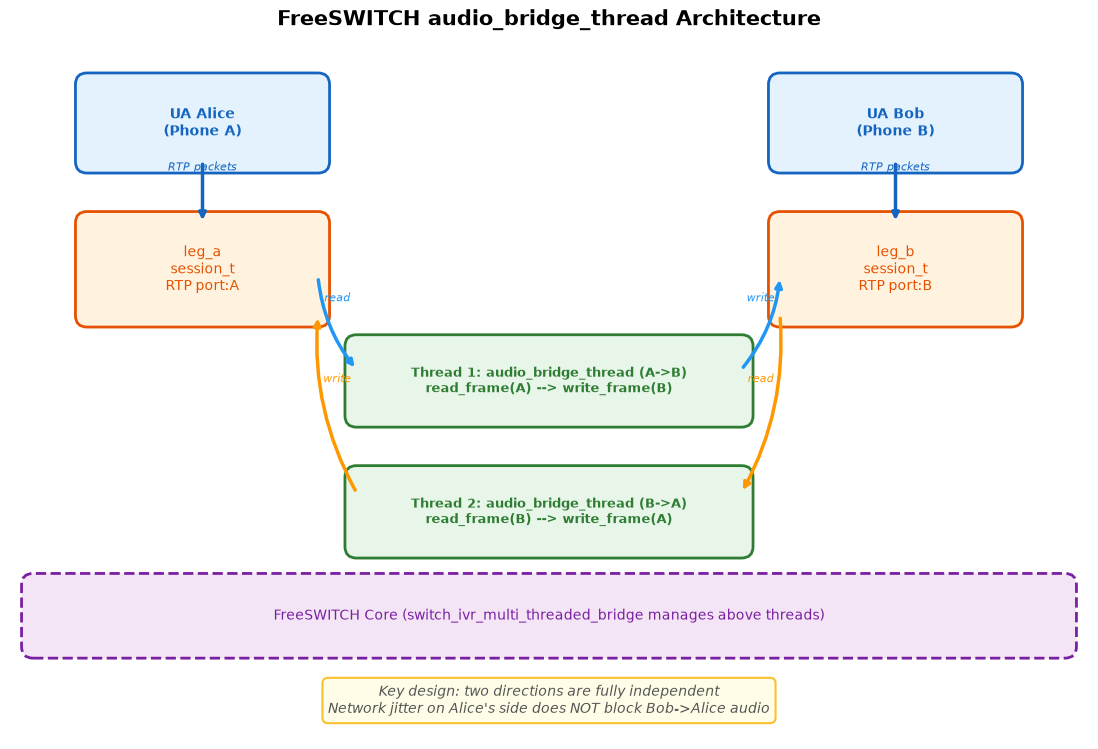

✅ Architecture diagram rendered


In [7]:
fig, ax = plt.subplots(1, 1, figsize=(14, 9))
ax.set_xlim(0, 14)
ax.set_ylim(0, 9)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title("FreeSWITCH audio_bridge_thread Architecture",
             fontsize=15, fontweight='bold', pad=15)

C = {
    "ua": "#E3F2FD", "ua_edge": "#1565C0",
    "leg": "#FFF3E0", "leg_edge": "#E65100",
    "bridge": "#E8F5E9", "bridge_edge": "#2E7D32",
    "core": "#F3E5F5", "core_edge": "#7B1FA2",
    "arrow_ab": "#2196F3", "arrow_ba": "#FF9800",
}

def box(x, y, w, h, text, fill, edge, fontsize=10, bold=False):
    r = mpatches.FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.15",
                                 facecolor=fill, edgecolor=edge, lw=2)
    ax.add_patch(r)
    weight = 'bold' if bold else 'normal'
    ax.text(x + w/2, y + h/2, text, ha='center', va='center',
            fontsize=fontsize, fontweight=weight, color=edge)

def arrow(x1, y1, x2, y2, color, label="", curve=0):
    style = f"arc3,rad={curve}" if curve else "arc3,rad=0"
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="-|>", color=color, lw=2.5,
                                connectionstyle=style))
    if label:
        mx, my = (x1+x2)/2, (y1+y2)/2
        ax.text(mx, my + 0.25, label, ha='center', va='bottom', fontsize=8,
                color=color, fontstyle='italic')

# UA boxes
box(1, 7.5, 3, 1, "UA Alice\n(Phone A)", C["ua"], C["ua_edge"], bold=True)
box(10, 7.5, 3, 1, "UA Bob\n(Phone B)", C["ua"], C["ua_edge"], bold=True)

# Call Legs
box(1, 5.5, 3, 1.2, "leg_a\nsession_t\nRTP port:A", C["leg"], C["leg_edge"])
box(10, 5.5, 3, 1.2, "leg_b\nsession_t\nRTP port:B", C["leg"], C["leg_edge"])

# UA -> Leg arrows
arrow(2.5, 7.5, 2.5, 6.7, C["ua_edge"], "RTP packets")
arrow(11.5, 7.5, 11.5, 6.7, C["ua_edge"], "RTP packets")

# Bridge threads
box(4.5, 4.2, 5, 0.9,
    "Thread 1: audio_bridge_thread (A->B)\nread_frame(A) --> write_frame(B)",
    C["bridge"], C["bridge_edge"], fontsize=9, bold=True)
box(4.5, 2.5, 5, 0.9,
    "Thread 2: audio_bridge_thread (B->A)\nread_frame(B) --> write_frame(A)",
    C["bridge"], C["bridge_edge"], fontsize=9, bold=True)

# Data flow arrows
arrow(4, 6.0, 4.5, 4.8, C["arrow_ab"], "read", 0.15)
arrow(9.5, 4.8, 10, 6.0, C["arrow_ab"], "write", 0.15)
arrow(10, 5.5, 9.5, 3.2, C["arrow_ba"], "read", -0.15)
arrow(4.5, 3.2, 4, 5.5, C["arrow_ba"], "write", -0.15)

# Core box
r = mpatches.FancyBboxPatch((0.3, 1.2), 13.4, 0.8, boxstyle="round,pad=0.15",
                             facecolor=C["core"], edgecolor=C["core_edge"], lw=2, ls='--')
ax.add_patch(r)
ax.text(7, 1.6,
        "FreeSWITCH Core (switch_ivr_multi_threaded_bridge manages above threads)",
        ha='center', va='center', fontsize=10, color=C["core_edge"])

# Annotation
ax.text(7, 0.5,
        "Key design: two directions are fully independent\n"
        "Network jitter on Alice's side does NOT block Bob->Alice audio",
        ha='center', va='center', fontsize=10, fontstyle='italic', color='#555',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#FFFDE7', edgecolor='#FBC02D', lw=1.5))

plt.show()
print("\u2705 Architecture diagram rendered")


## 8️⃣ 实验：模拟阻塞对桥接的影响 🔬

**核心问题**：如果 A->B 方向的读取被阻塞（比如一个慢的外部 API 调用），B->A 方向还能正常工作吗？

下面我们注入一个 **500ms 的人工阻塞** 到 A->B 方向的桥接中，观察它是否影响 B->A 方向。


In [8]:
def audio_bridge_thread_with_block(read_leg, write_leg, direction, bridge_active,
                                   stats, t0, block_at_frame=None, block_duration=0):
    """Bridge thread with optional blocking injection"""
    bridged = 0
    frame_times = []

    while bridge_active.is_set():
        frame = read_leg.read_frame(t0)
        if frame is None:
            continue
        if len(frame) < RTP_HEADER_SIZE:
            continue

        # Inject blocking (simulates slow API call in dialplan)
        if block_at_frame is not None and bridged == block_at_frame:
            print(f"  \u26a0\ufe0f [{direction}] Injecting {block_duration*1000:.0f}ms block at frame {bridged}!")
            time.sleep(block_duration)
            print(f"  \u2705 [{direction}] Block released, resuming bridge")

        if write_leg.write_frame(frame, t0):
            frame_times.append(time.monotonic() - t0)
            bridged += 1

    stats[direction] = {"count": bridged, "times": frame_times}

# Use different ports to avoid conflict
PORT_A2, PORT_B2 = 18000, 18002
PORT_AP2, PORT_BP2 = 18010, 18012

leg_a2 = CallLeg(name="leg_a", rtp_port=PORT_A2, peer_port=PORT_BP2)
leg_b2 = CallLeg(name="leg_b", rtp_port=PORT_B2, peer_port=PORT_AP2)
leg_a2.setup()
leg_b2.setup()

bridge_active2 = threading.Event()
bridge_active2.set()
block_stats = {}
send_log_a2, send_log_b2 = [], []
t0_2 = time.monotonic()
TOTAL2 = 50

print("\U0001f52c Experiment: Injecting 500ms block at A->B frame #15\n")

threads2 = [
    threading.Thread(target=audio_bridge_thread_with_block,
                     args=(leg_a2, leg_b2, "A->B", bridge_active2, block_stats, t0_2, 15, 0.5)),
    threading.Thread(target=audio_bridge_thread_with_block,
                     args=(leg_b2, leg_a2, "B->A", bridge_active2, block_stats, t0_2, None, 0)),
    threading.Thread(target=ua_producer,
                     args=("UA_A", PORT_A2, 0xCC01, bridge_active2, TOTAL2, t0_2, send_log_a2)),
    threading.Thread(target=ua_producer,
                     args=("UA_B", PORT_B2, 0xDD02, bridge_active2, TOTAL2, t0_2, send_log_b2)),
]

for t in threads2:
    t.start()
threads2[2].join()
threads2[3].join()
time.sleep(0.5)
bridge_active2.clear()
for t in threads2[:2]:
    t.join()

a2b_block = block_stats.get("A->B", {})
b2a_block = block_stats.get("B->A", {})

print(f"\n{'='*50}")
print(f"  \U0001f4ca Blocking Experiment Results")
print(f"{'='*50}")
print(f"  A->B (BLOCKED): {a2b_block.get('count', 0)}/{TOTAL2} frames")
print(f"  B->A (normal):  {b2a_block.get('count', 0)}/{TOTAL2} frames")

if b2a_block.get("count", 0) >= TOTAL2 * 0.8:
    print(f"\n  \u2705 KEY FINDING: B->A direction is NOT affected by A->B blocking!")
    print(f"     This proves the thread isolation design of multi_threaded_bridge")
else:
    print(f"\n  \u26a0\ufe0f B->A direction was also affected")

leg_a2.close()
leg_b2.close()


🔬 Experiment: Injecting 500ms block at A->B frame #15

  ⚠️ [A->B] Injecting 500ms block at frame 15!
  ✅ [A->B] Block released, resuming bridge

  📊 Blocking Experiment Results
  A->B (BLOCKED): 50/50 frames
  B->A (normal):  50/50 frames

  ✅ KEY FINDING: B->A direction is NOT affected by A->B blocking!
     This proves the thread isolation design of multi_threaded_bridge


## 9️⃣ 可视化：阻塞影响对比

下图清晰展示：A->B 方向在第 15 帧处出现 500ms 的空白（阻塞），而 B->A 方向完全不受影响，帧均匀分布。

这就是 `switch_ivr_multi_threaded_bridge` 的核心设计价值。


/var/folders/xk/0l93y7ps37lck71fry36ycxh0000gn/T/ipykernel_36940/3503123091.py:25: UserWarning: Glyph 129525 (\N{SPOOL OF THREAD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


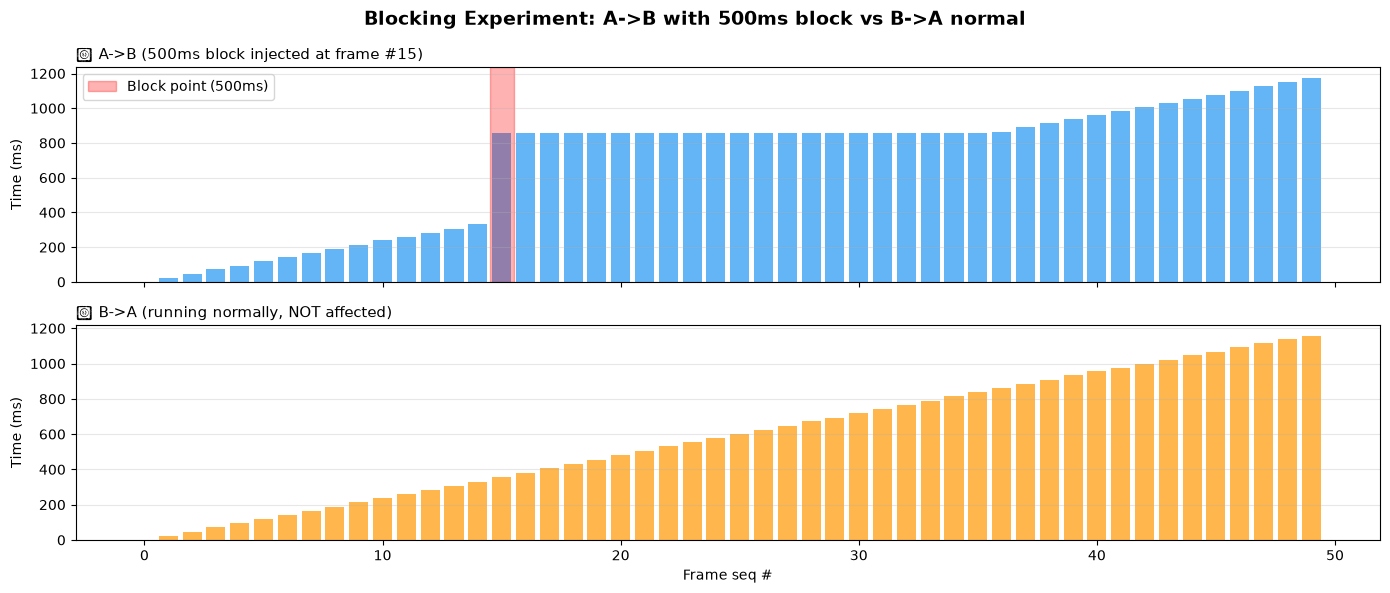

✅ Blocking experiment chart rendered


In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
fig.suptitle("Blocking Experiment: A->B with 500ms block vs B->A normal",
             fontsize=14, fontweight='bold')

for ax, direction, data, color, title in [
    (axes[0], "A->B", a2b_block, "#2196F3",
     "\U0001f9f5 A->B (500ms block injected at frame #15)"),
    (axes[1], "B->A", b2a_block, "#FF9800",
     "\U0001f9f5 B->A (running normally, NOT affected)"),
]:
    times = data.get("times", [])
    if times:
        ax.bar(range(len(times)), [t * 1000 for t in times],
               color=color, alpha=0.7, width=0.8)

        if direction == "A->B" and len(times) > 15:
            ax.axvspan(14.5, 15.5, alpha=0.3, color='red', label='Block point (500ms)')
            ax.legend(fontsize=10)

    ax.set_ylabel("Time (ms)")
    ax.set_title(title, fontsize=11, loc='left')
    ax.grid(True, alpha=0.3, axis='y')

axes[1].set_xlabel("Frame seq #")
plt.tight_layout()
plt.show()
print("\u2705 Blocking experiment chart rendered")


## \U0001f51f 可视化：线程甘特图

把所有线程的活动画成甘特图（Gantt Chart），展示并发执行的全貌。红色区域标记了注入的 500ms 阻塞。


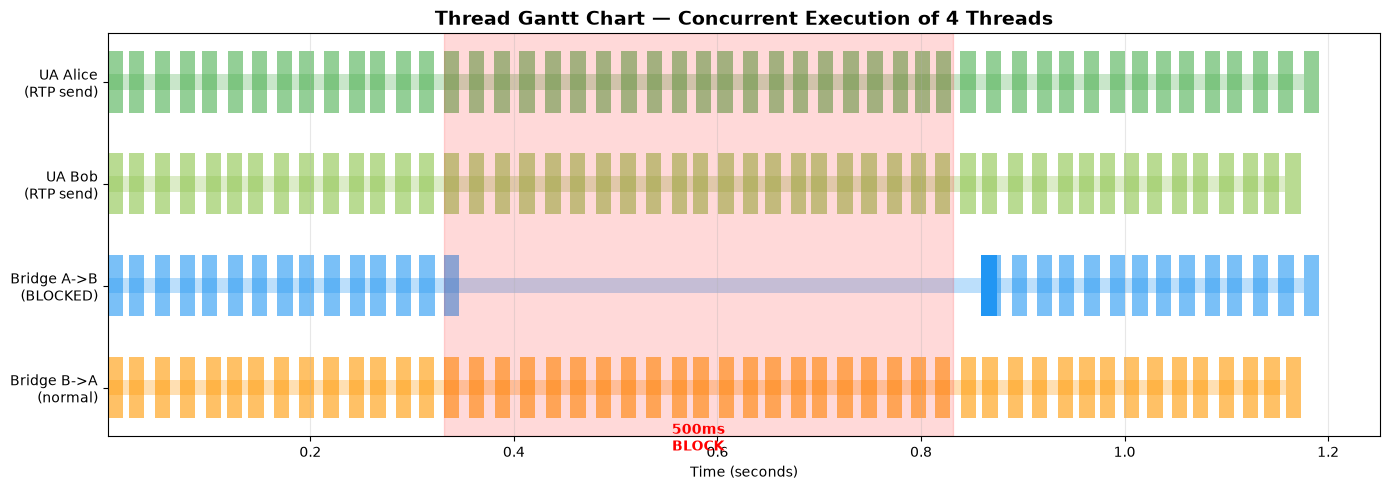

✅ Gantt chart rendered


In [10]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.set_title("Thread Gantt Chart \u2014 Concurrent Execution of 4 Threads",
             fontsize=14, fontweight='bold')

ab_times = a2b_block.get("times", [])
ba_times = b2a_block.get("times", [])
sa_times = [t for t, s in send_log_a2]
sb_times = [t for t, s in send_log_b2]

thread_data = [
    ("UA Alice\n(RTP send)", sa_times, "#4CAF50"),
    ("UA Bob\n(RTP send)", sb_times, "#8BC34A"),
    ("Bridge A->B\n(BLOCKED)", ab_times, "#2196F3"),
    ("Bridge B->A\n(normal)", ba_times, "#FF9800"),
]

for i, (label, times, color) in enumerate(thread_data):
    if times:
        y = i
        for t in times:
            ax.barh(y, 0.015, left=t, height=0.6, color=color, alpha=0.6)
        ax.barh(y, max(times) - min(times), left=min(times), height=0.15,
                color=color, alpha=0.3)

if ab_times and len(ab_times) > 15:
    block_start = ab_times[14] if len(ab_times) > 14 else 0.3
    ax.axvspan(block_start, block_start + 0.5, alpha=0.15, color='red')
    ax.text(block_start + 0.25, 3.5, "500ms\nBLOCK", ha='center', va='center',
            fontsize=10, color='red', fontweight='bold')

ax.set_yticks(range(len(thread_data)))
ax.set_yticklabels([d[0] for d in thread_data], fontsize=10)
ax.set_xlabel("Time (seconds)")
ax.grid(True, alpha=0.3, axis='x')
ax.invert_yaxis()

plt.tight_layout()
plt.show()
print("\u2705 Gantt chart rendered")


## 📝 总结：源码映射表

| 本 Notebook 中的代码 | FreeSWITCH 真实源码 | 文件 |
|---|---|---|
| `CallLeg` 类 | `switch_core_session_t` 结构体 | `src/include/switch_core.h` |
| `audio_bridge_thread()` | `audio_bridge_thread()` | `src/switch_ivr_bridge.c` |
| Cell 4 中的线程创建 | `switch_ivr_multi_threaded_bridge()` | `src/switch_ivr_bridge.c` |
| `read_frame()` -> `recvfrom()` | `switch_core_session_read_frame()` -> `switch_rtp_zerocopy_read_frame()` -> `recvfrom()`/timer | `src/switch_core_io.c` -> `src/switch_rtp.c` |
| `write_frame()` -> `sendto()` | `switch_core_session_write_frame()` -> codec convert -> `sendto()` | `src/switch_core_io.c` |
| `bridge_active` Event | channel flags / bridge state | `src/switch_ivr_bridge.c` |
| Cell 8 的阻塞注入 | dialplan 中的慢 HTTP/DB 调用 | 任何阻塞的 app |

### 核心洞察

1. **每个桥接方向一个线程** — `read_frame()` 阻塞不会跨方向传播
2. **RTP 由 session 线程同步处理** — 不存在独立的 RTP 接收线程（音频）
3. **线程隔离是有限的** — 阻塞不跨方向传播，但会消耗 session/线程资源，大量堆积会影响全局

GitHub: https://github.com/signalwire/freeswitch/blob/master/src/switch_ivr_bridge.c
